# Chapter 8: Tree-Based Algorithms and Ensemble Methods

This notebook reproduces the code and summarizes the concepts from **scikit-learn Cookbook (3rd Edition)**, published by Packt, Chapter 8. The explanations below have been rewritten in my own words rather than copied verbatim from the book.

Not every ML algorithm requires heavy mathematical machinery to understand — **tree-based algorithms** are a good example. They work by recursively splitting the data to perform classification or regression. In practice, these trees are frequently combined through **ensemble** techniques for a meaningful boost in predictive performance.

**In this chapter, we cover the following recipes:**
- Introduction to decision trees
- Random forests and bagging
- Gradient boosting machines
- Hyperparameter tuning for trees and ensembles
- Comparing ensemble methods


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

%matplotlib inline


## Introduction to Decision Trees

A decision tree works by repeatedly splitting the dataset based on feature values, building a tree-like structure of **nodes** (decision points) and **branches**. Each internal node represents a decision based on a single feature, while **leaf nodes** hold the final predicted outcome.

The main appeal of decision trees is interpretability — the path from root to leaf gives a readable, step-by-step explanation for any prediction. Splits are typically chosen to minimize an impurity measure such as **Gini impurity**:

$$\text{Gini} = 1 - \sum_{k=1}^{K} p_k^2$$

where $p_k$ is the proportion of class $k$ samples in a node. A Gini of $0$ means the node is perfectly pure (only one class present).

In [2]:
iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

clf = DecisionTreeClassifier(random_state=2024)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy:.3f}")
pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose().round(3)


Decision Tree Accuracy: 0.867


,precision,recall,f1-score,support
0,1.000,1.000,1.000,18.000
1,0.714,0.833,0.769,12.000
2,0.846,0.733,0.786,15.000
accuracy,0.867,0.867,0.867,0.867
macro avg,0.853,0.856,0.852,45.000
weighted avg,0.873,0.867,0.867,45.000


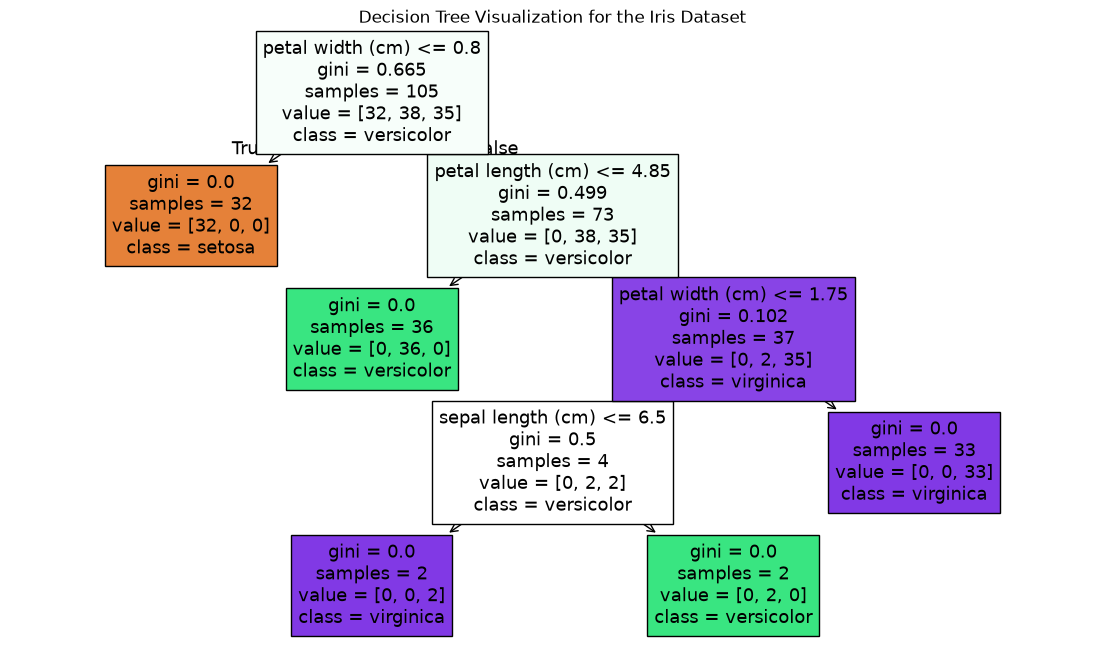

In [3]:
plt.figure(figsize=(14, 8))
plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.title("Decision Tree Visualization for the Iris Dataset")
plt.show()


A single unconstrained decision tree already reaches **$86.7\%$** accuracy on Iris. Reading the tree diagram: each node shows the feature and threshold used for the split, the Gini impurity, the proportion of samples reaching that node, and the majority class.

### Key hyperparameters
- `max_depth`: limits how many levels the tree can grow — a direct trade-off between model complexity and node purity.
- `min_samples_split` / `min_samples_leaf`: minimum number of samples required before a node can be split / become a leaf.
- `max_features`: caps how many features are considered when searching for the best split.
- `min_impurity_decrease`: a split only happens if it reduces impurity by at least this amount.

These parameters are the primary levers for controlling tree complexity and preventing overfitting.

## Random Forests and Bagging

A single decision tree tends to overfit easily. **Random forests** address this using **bootstrap aggregating (bagging)**: many trees are each trained on a different bootstrap sample of the data (sampled with replacement), and the final prediction comes from a majority vote (classification) or average (regression) across all trees.

In [4]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=2024)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

print(f"Single Decision Tree Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Random Forest Accuracy       : {accuracy_score(y_test, y_pred_rf):.3f}")


Single Decision Tree Accuracy: 0.867
Random Forest Accuracy       : 0.911


Random forest improved accuracy from $86.7\%$ to **$91.1\%$** — a clear demonstration of how combining many trees reduces variance and improves generalization compared to any single tree. We can also inspect which features drive the model's decisions via *feature importance*.

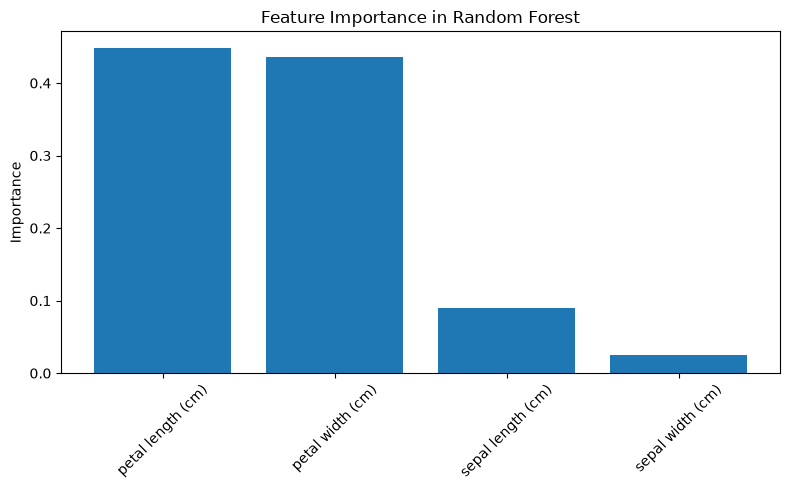

In [5]:
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), [iris.feature_names[i] for i in indices], rotation=45)
plt.ylabel('Importance')
plt.title('Feature Importance in Random Forest')
plt.tight_layout()
plt.show()


*Petal length* and *petal width* once again stand out as the most important features for classifying Iris species — consistent with what the single decision tree visualization already suggested. Random forests are sometimes used purely for feature selection, feeding the most important features forward into a different downstream model.

**Side note:** bagging is not limited to decision trees — it can be applied to other base models too, via `BaggingClassifier()` and `BaggingRegressor()`.

## Gradient Boosting Machines (GBM)

While random forest builds trees **in parallel** (independently), **gradient boosting** builds them **sequentially** — each new tree is trained specifically to correct the errors (residuals) of the trees that came before it. This progressive error-correction is where the term "boosting" comes from.

In [6]:
gbm_clf = GradientBoostingClassifier(n_estimators=1000, learning_rate=0.2, random_state=2024)
gbm_clf.fit(X_train, y_train)
y_pred_gbm = gbm_clf.predict(X_test)

print(f"GBM Accuracy: {accuracy_score(y_test, y_pred_gbm):.3f}")
pd.DataFrame(classification_report(y_test, y_pred_gbm, output_dict=True)).transpose().round(3)


GBM Accuracy: 0.867


,precision,recall,f1-score,support
0,1.000,1.000,1.000,18.000
1,0.714,0.833,0.769,12.000
2,0.846,0.733,0.786,15.000
accuracy,0.867,0.867,0.867,0.867
macro avg,0.853,0.856,0.852,45.000
weighted avg,0.873,0.867,0.867,45.000


Interestingly, GBM's result ($86.7\%$) lands exactly on par with the single decision tree — a sign that both models may be converging to a performance ceiling on this relatively simple dataset, rather than one approach being strictly superior to the other. This gets revisited in the hyperparameter tuning section below.

### How GBM works
GBM iteratively fits new models to predict the **residuals** (errors) of the previous ensemble, gradually refining the overall prediction.

- **Early stopping**: halts the fitting process early to avoid overfitting — without it, a tree can keep splitting until every training sample sits in its own leaf.
- **Validation curves**: compare training vs. validation performance across hyperparameter values, useful for spotting underfitting (both scores low) vs. overfitting (training high, validation low).

## Hyperparameter Tuning for Trees and Ensembles

As with other algorithms, decision tree, random forest, and GBM performance can be improved by tuning hyperparameters such as `max_depth`, `n_estimators`, and `learning_rate`. We use `GridSearchCV` to find the best GBM configuration.

In [7]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=2024), param_grid, cv=5, scoring='accuracy'
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print(f"Accuracy after tuning: {accuracy_score(y_test, y_pred):.3f}")


Best parameters: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 50}
Accuracy after tuning: 0.867


Tuning once again lands on the same $86.7\%$ accuracy — not a failed search, but rather a reflection of the dataset itself: Iris is simple enough that many reasonable hyperparameter configurations converge to a similar performance ceiling.

Let's visualize how the combination of `max_depth` and `n_estimators` affects cross-validation score.

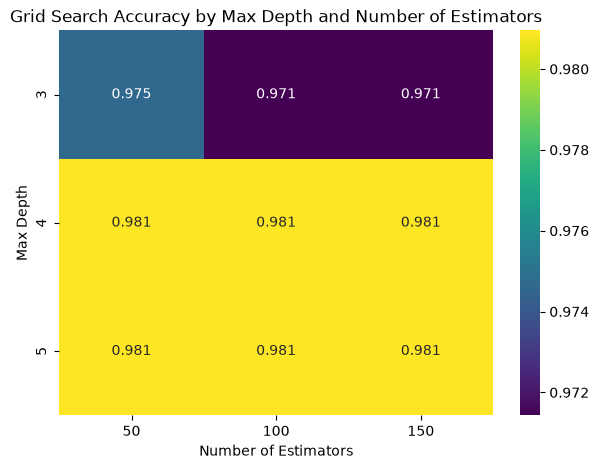

In [8]:
results = pd.DataFrame(grid_search.cv_results_)
pivot_table = results.pivot_table(
    values='mean_test_score', index='param_max_depth', columns='param_n_estimators'
)

plt.figure(figsize=(7, 5))
sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='viridis')
plt.title('Grid Search Accuracy by Max Depth and Number of Estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('Max Depth')
plt.show()


The heatmap shows a clear plateau — once `max_depth` and `n_estimators` pass a certain point, accuracy stops improving meaningfully. This is a useful reminder that piling on more model complexity isn't always worthwhile, and can just slow down training for no real gain.

Besides exhaustive `GridSearchCV`, `RandomizedSearchCV` samples combinations randomly — often reaching comparable results at a fraction of the computational cost.

## Comparing Ensemble Methods

Finally, let's compare three ensemble approaches side by side: **bagging** (random forest), **boosting** (gradient boosting), and **stacking** (combining several base models through a meta-model).

In [9]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=2024)
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=2024)
stacking_clf = StackingClassifier(
    estimators=[('rf', rf_clf), ('gb', gb_clf)],
    final_estimator=LogisticRegression(),
    cv=5
)

rf_clf.fit(X_train, y_train)
gb_clf.fit(X_train, y_train)
stacking_clf.fit(X_train, y_train)

rf_accuracy = accuracy_score(y_test, rf_clf.predict(X_test))
gb_accuracy = accuracy_score(y_test, gb_clf.predict(X_test))
stacking_accuracy = accuracy_score(y_test, stacking_clf.predict(X_test))

print(f"Random Forest Accuracy    : {rf_accuracy:.3f}")
print(f"Gradient Boosting Accuracy: {gb_accuracy:.3f}")
print(f"Stacking Accuracy         : {stacking_accuracy:.3f}")


Random Forest Accuracy    : 0.911
Gradient Boosting Accuracy: 0.867
Stacking Accuracy         : 0.867


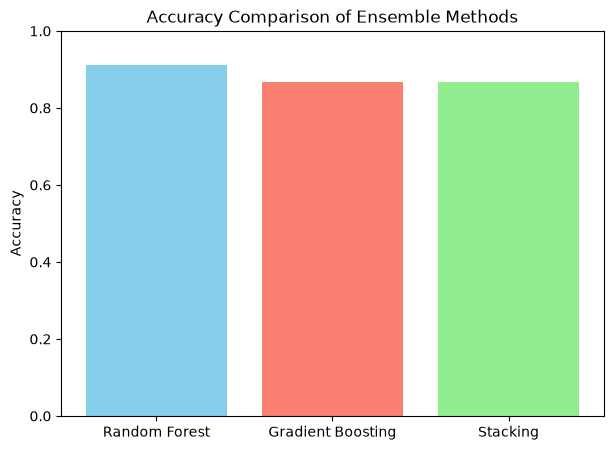

In [10]:
methods = ['Random Forest', 'Gradient Boosting', 'Stacking']
accuracies = [rf_accuracy, gb_accuracy, stacking_accuracy]

plt.figure(figsize=(7, 5))
plt.bar(methods, accuracies, color=['skyblue', 'salmon', 'lightgreen'])
plt.title('Accuracy Comparison of Ensemble Methods')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()


Random forest comes out slightly ahead of both GBM and stacking ($91.1\%$ vs. $86.7\%$ for both) on this run. Each method has a distinct character:

- **Bagging (random forest)**: averages predictions across many trees trained on bootstrap resamples — primarily reduces **variance**.
- **Boosting (GBM)**: builds trees sequentially to correct the previous ensemble's errors — primarily reduces **bias**.
- **Stacking**: blends predictions from several base models through one meta-model, aiming to combine their individual strengths into something better than any single model alone.

Worth noting: stacking didn't beat random forest here, which is a good reminder that more sophisticated ensembling doesn't automatically guarantee better results — it depends heavily on how much the base models' errors actually complement each other.

---
## Chapter Summary

- Decision trees split data recursively based on feature values; they're highly interpretable but prone to overfitting without constraints like `max_depth` or `min_samples_split`. A single tree reached $86.7\%$ accuracy on Iris.
- **Random forest (bagging)** combines many trees trained in parallel on bootstrap samples, reducing variance — accuracy jumped to $91.1\%$ on the same data.
- **Gradient boosting** builds trees sequentially to correct prior residuals, reducing bias — though on this dataset it matched the single tree's accuracy rather than beating it.
- Hyperparameter tuning (`max_depth`, `n_estimators`, `learning_rate`) via grid/random search remains important, even if its effect can be limited on simple, well-separated datasets like Iris.
- **Stacking** combines multiple base models through a meta-model as an alternative to bagging and boosting — it doesn't automatically outperform simpler ensembles, since its benefit depends on how complementary the base models' errors are.